# Chapter 6 - Dual Affine Connections and Dually Flat Manifolds

Standalone computational companion for printed pages 131-161 and PDF pages 141-171. The chapter question is: how can one metric support two different notions of straightness, and why does that split become useful for inference, neural systems, and integrated information?

This notebook uses original prose and computational reconstructions only. It does not rely on copied textbook text or page images.

## Translation Guide

- A **Riemannian metric** measures tangent vectors. In statistical models it is typically the Fisher information.
- A **dual pair of affine connections** gives two compatible ways to differentiate vector fields. Compatibility means that differentiating an inner product by one connection can be balanced by differentiating the two vectors with opposite connections.
- A **dually flat manifold** has coordinates `theta` flat for one connection and coordinates `eta` flat for the dual connection.
- A **potential** `psi(theta)` generates `eta = grad psi(theta)`. Its Legendre dual `phi(eta)` generates `theta = grad phi(eta)`.
- The **canonical divergence** is the Bregman gap `psi(theta_p) + phi(eta_q) - theta_p dot eta_q`.
- **Mixed coordinates** keep part of a point in `theta` and the rest in `eta`; orthogonal slices make the generalized Pythagorean identity visible.
- **k-cuts** and **integrated information** ask how much structure is lost when a coupled system is forced to factor across a partition.

## Route

1. Draw the same simplex with mixture-straight and exponential-straight paths.
2. Derive canonical divergence from a convex potential and render its asymmetric surface.
3. Use mixed coordinates to see a Pythagorean decomposition.
4. Compare coupled systems with k-cuts.
5. Run an applied lab measuring information lost by partitioning a small neural transition model.


In [1]:
from pathlib import Path
import json, math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import plotly.graph_objects as go
from IPython.display import Image, HTML, JSON, display

HERE = Path.cwd()
BOOK_ROOT = next(p for p in [HERE, *HERE.parents] if (p / 'Information Geometry and Its Applications.pdf').exists())
ARTIFACT_DIR = BOOK_ROOT / 'artifacts' / 'chapter-06'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

def display_artifact(name, kind='image', width=None, height=520):
    path = ARTIFACT_DIR / name
    if kind == 'image':
        display(Image(filename=str(path), width=width))
    elif kind == 'html':
        display(HTML(path.read_text(encoding='utf-8')))
    elif kind == 'json':
        display(JSON(json.loads(path.read_text(encoding='utf-8'))))
    return path

def savefig(fig, name):
    path = ARTIFACT_DIR / name
    fig.savefig(path, dpi=180, bbox_inches='tight')
    plt.close(fig)
    return path

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def logit(p):
    p = np.clip(np.asarray(p, dtype=float), 1e-12, 1 - 1e-12)
    return np.log(p / (1 - p))

def kl_bernoulli(p, q):
    p = np.clip(np.asarray(p, dtype=float), 1e-12, 1 - 1e-12)
    q = np.clip(np.asarray(q, dtype=float), 1e-12, 1 - 1e-12)
    return p * np.log(p / q) + (1 - p) * np.log((1 - p) / (1 - q))

def psi_bernoulli(theta):
    theta = np.asarray(theta, dtype=float)
    return np.logaddexp(0.0, theta)

def phi_bernoulli(eta):
    eta = np.clip(np.asarray(eta, dtype=float), 1e-12, 1 - 1e-12)
    return eta * np.log(eta) + (1 - eta) * np.log(1 - eta)

def canonical_bernoulli(p, q):
    theta_p = logit(p)
    eta_q = np.asarray(q, dtype=float)
    return psi_bernoulli(theta_p) + phi_bernoulli(eta_q) - theta_p * eta_q

artifact_names = []


## 1. One Metric, Two Straightness Rules

On a probability simplex, mixture coordinates are the probabilities themselves. A mixture geodesic is therefore an ordinary line segment in the simplex. Exponential coordinates are log-odds up to an additive normalization. An exponential geodesic is straight in log coordinates, then curves after normalization back onto the simplex.

The metric does not change between these views. What changes is the rule for declaring a transported vector unchanged. This is the computational heart of dual connections: one connection is natural for averaging probabilities, the other is natural for multiplying and renormalizing likelihood factors.


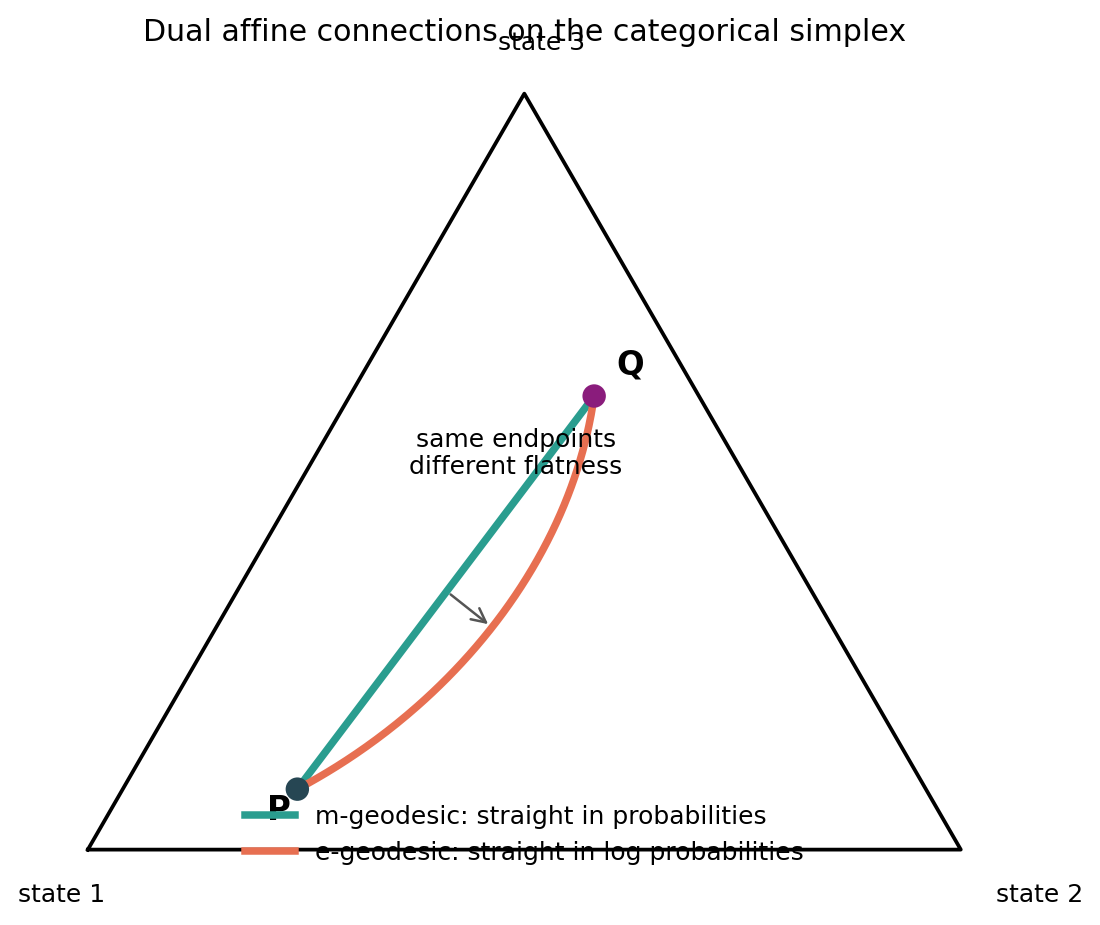

WindowsPath('D:/Geometry/Information-Geometry-and-Its-Applications/artifacts/chapter-06/dual_connections_simplex.png')

In [2]:
def ternary(p):
    p = np.asarray(p, dtype=float)
    return np.column_stack([p[..., 1] + 0.5 * p[..., 2], (math.sqrt(3) / 2) * p[..., 2]])

def normalize(p):
    p = np.asarray(p, dtype=float)
    return p / p.sum(axis=-1, keepdims=True)

def m_path(p, q, t):
    return normalize((1 - t)[:, None] * p + t[:, None] * q)

def e_path(p, q, t):
    logp = np.log(np.clip(p, 1e-12, None))
    logq = np.log(np.clip(q, 1e-12, None))
    z = (1 - t)[:, None] * logp + t[:, None] * logq
    z -= z.max(axis=1, keepdims=True)
    return normalize(np.exp(z))

p = np.array([0.72, 0.20, 0.08])
q = np.array([0.12, 0.28, 0.60])
t = np.linspace(0, 1, 160)
mp = m_path(p, q, t)
ep = e_path(p, q, t)
tri = ternary(np.eye(3))

fig, ax = plt.subplots(figsize=(7.2, 6.0))
ax.plot(*np.r_[tri, tri[:1]].T, color='black', lw=1.5)
ax.plot(*ternary(mp).T, color='#2a9d8f', lw=3, label='m-geodesic: straight in probabilities')
ax.plot(*ternary(ep).T, color='#e76f51', lw=3, label='e-geodesic: straight in log probabilities')
ax.scatter(*ternary(np.vstack([p, q])).T, s=70, color=['#264653', '#8a1c7c'], zorder=4)
for label, point, offset in [('P', p, (-0.035, -0.035)), ('Q', q, (0.025, 0.025))]:
    xy = ternary(point[None, :])[0]
    ax.text(xy[0] + offset[0], xy[1] + offset[1], label, fontsize=13, weight='bold')
for i, label in enumerate(['state 1', 'state 2', 'state 3']):
    ax.text(tri[i,0] + [-0.08, 0.04, -0.03][i], tri[i,1] + [-0.06, -0.06, 0.05][i], label)
mid_m = ternary(mp[80:81])[0]
mid_e = ternary(ep[80:81])[0]
ax.add_patch(FancyArrowPatch(mid_m, mid_e, arrowstyle='->', mutation_scale=14, color='#555555'))
ax.text(0.49, 0.43, 'same endpoints\ndifferent flatness', ha='center', fontsize=10)
ax.set_aspect('equal')
ax.axis('off')
ax.legend(loc='lower center', frameon=False)
ax.set_title('Dual affine connections on the categorical simplex')
artifact_names.append('dual_connections_simplex.png')
savefig(fig, artifact_names[-1])
display_artifact(artifact_names[-1])


## 2. Canonical Divergence as a Convex Gap

In a dually flat chart, a convex potential `psi(theta)` turns natural coordinates into expectation coordinates by `eta = grad psi(theta)`. The Legendre transform `phi(eta)` reverses the map. The canonical divergence between `P` and `Q` is

```text
D(P, Q) = psi(theta_P) + phi(eta_Q) - theta_P * eta_Q.
```

For a Bernoulli model this is the same numeric quantity as `KL(Q || P)` under the orientation used here. The useful lesson is not the name of the divergence alone, but the shape: the gap vanishes on the diagonal, is nonnegative, and is asymmetric away from the diagonal.


In [3]:
grid = np.linspace(0.02, 0.98, 80)
P, Q = np.meshgrid(grid, grid)
D = canonical_bernoulli(P, Q)
D_reverse = canonical_bernoulli(Q, P)
asymmetry = D - D_reverse

fig = go.Figure(data=[
    go.Surface(x=P, y=Q, z=D, colorscale='Viridis', colorbar=dict(title='D(P,Q)'))
])
fig.update_layout(
    title='Canonical divergence on the Bernoulli dually flat manifold',
    scene=dict(xaxis_title='p = eta(P)', yaxis_title='q = eta(Q)', zaxis_title='divergence'),
    width=780,
    height=560,
    margin=dict(l=0, r=0, t=45, b=0),
)
artifact_names.append('canonical_divergence_surface.html')
fig.write_html(ARTIFACT_DIR / artifact_names[-1], include_plotlyjs='cdn', full_html=True)
display_artifact(artifact_names[-1], kind='html')

max_identity_error = float(np.max(np.abs(D - kl_bernoulli(Q, P))))
min_divergence = float(D.min())
diagonal_error = float(np.max(np.abs(canonical_bernoulli(grid, grid))))
asymmetry_sample = float(canonical_bernoulli(0.2, 0.8) - canonical_bernoulli(0.8, 0.2))
print('max canonical/KL orientation error:', max_identity_error)
print('minimum grid divergence:', min_divergence)
print('max diagonal error:', diagonal_error)
print('sample asymmetry D(.2,.8)-D(.8,.2):', asymmetry_sample)
assert max_identity_error < 1e-10
assert min_divergence >= -1e-12
assert diagonal_error < 1e-10


max canonical/KL orientation error: 8.881784197001252e-16
minimum grid divergence: -4.440892098500626e-16
max diagonal error: 4.440892098500626e-16
sample asymmetry D(.2,.8)-D(.8,.2): -2.220446049250313e-16


## 3. Mixed Coordinates and the Pythagorean Shape

Mixed coordinates splice two coordinate systems together. In a product Bernoulli model, choose one component in expectation form and the other in natural form. Holding `eta_1` fixed gives one flat sheet. Holding `theta_2` fixed gives a dual flat sheet. Their intersection is the point that behaves like an orthogonal projection.

The figure below uses independent Bernoulli variables because the algebra is transparent. The lesson transfers to richer dually flat manifolds: when a primal-flat and a dual-flat submanifold meet orthogonally, the canonical divergence decomposes like a squared Euclidean distance, even though the geometry is not Euclidean.


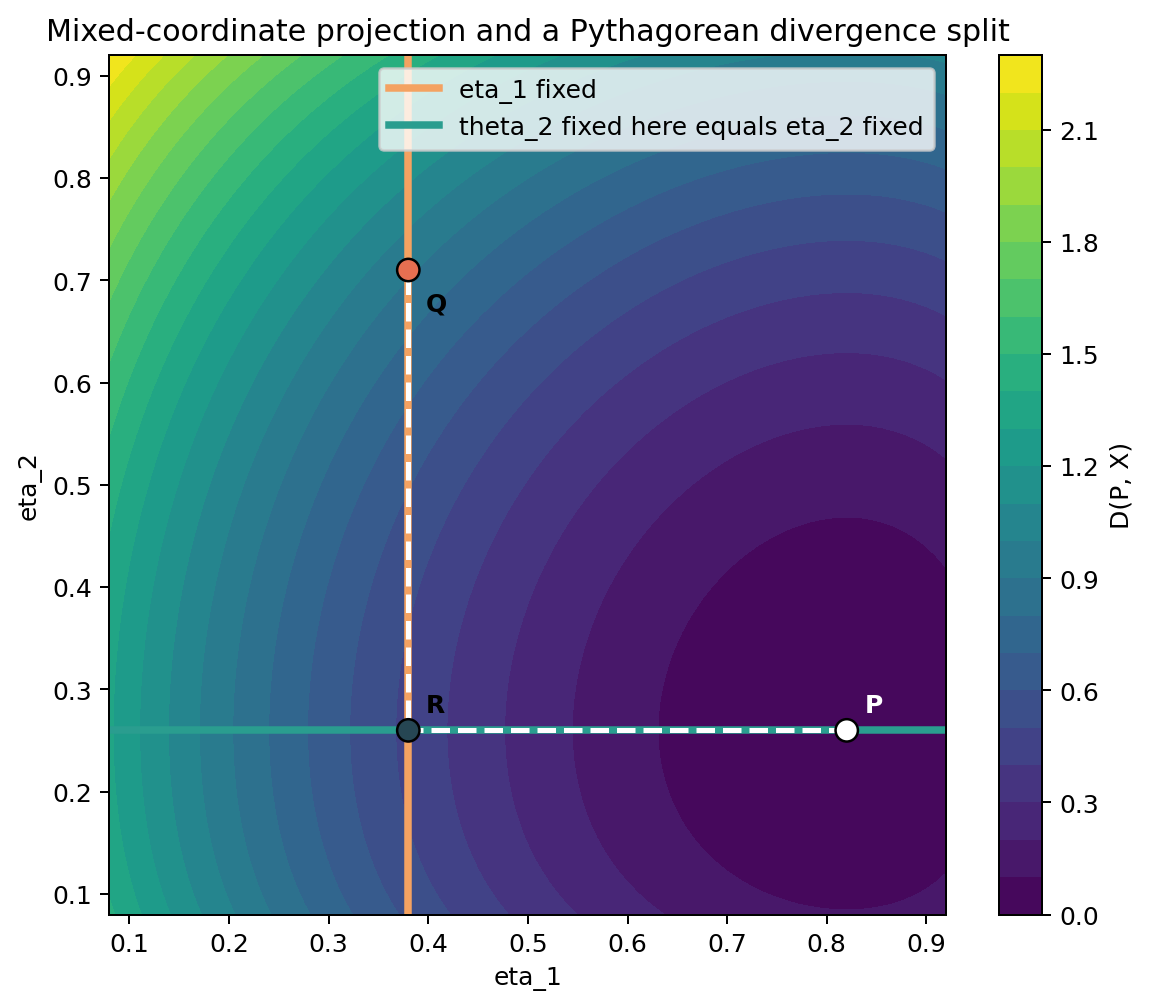

D(P,Q): 0.9161133399388945
D(P,R)+D(R,Q): 0.9161133399388945
residual: 0.0


In [4]:
def canonical_product(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    return float(np.sum(canonical_bernoulli(p, q)))

P0 = np.array([0.82, 0.26])
Q0 = np.array([0.38, 0.71])
R0 = np.array([Q0[0], P0[1]])
left = canonical_product(P0, Q0)
right = canonical_product(P0, R0) + canonical_product(R0, Q0)
pythagorean_residual = float(left - right)

u = np.linspace(0.08, 0.92, 80)
v = np.linspace(0.08, 0.92, 80)
U, V = np.meshgrid(u, v)
Z = np.zeros_like(U)
for i in range(U.shape[0]):
    for j in range(U.shape[1]):
        Z[i, j] = canonical_product(P0, np.array([U[i, j], V[i, j]]))

fig, ax = plt.subplots(figsize=(7.5, 6.2))
cs = ax.contourf(U, V, Z, levels=24, cmap='viridis')
fig.colorbar(cs, ax=ax, label='D(P, X)')
ax.axvline(R0[0], color='#f4a261', lw=3, label='eta_1 fixed')
ax.axhline(R0[1], color='#2a9d8f', lw=3, label='theta_2 fixed here equals eta_2 fixed')
ax.scatter([P0[0], Q0[0], R0[0]], [P0[1], Q0[1], R0[1]], s=80, color=['white', '#e76f51', '#264653'], edgecolor='black', zorder=5)
for label, point, dx, dy in [('P', P0, .018, .018), ('Q', Q0, .018, -.04), ('R', R0, .018, .018)]:
    ax.text(point[0] + dx, point[1] + dy, label, weight='bold', color='white' if label == 'P' else 'black')
ax.plot([P0[0], R0[0], Q0[0]], [P0[1], R0[1], Q0[1]], color='white', lw=2, ls='--')
ax.set_xlabel('eta_1')
ax.set_ylabel('eta_2')
ax.set_title('Mixed-coordinate projection and a Pythagorean divergence split')
ax.legend(frameon=True, loc='upper right')
artifact_names.append('mixed_coordinates_pythagorean.png')
savefig(fig, artifact_names[-1])
display_artifact(artifact_names[-1])
print('D(P,Q):', left)
print('D(P,R)+D(R,Q):', right)
print('residual:', pythagorean_residual)
assert abs(pythagorean_residual) < 1e-12


## 4. k-Cuts as Forced Factorizations

A cut asks what happens when a joint distribution is replaced by a model that preserves selected lower-order pieces and deletes the coupling across a partition. In a dually flat language, the fully coupled distribution is a point in a larger manifold. The cut distribution lies in a flatter, lower-interaction family. Their canonical divergence measures the interaction structure that the cut cannot express.

For two binary variables, the simplest cut keeps the two marginals and replaces the joint by their product. The lost information is mutual information. For three variables, different two-block cuts lose different amounts, so we can rank partitions by the divergence from the coupled system to the cut family.


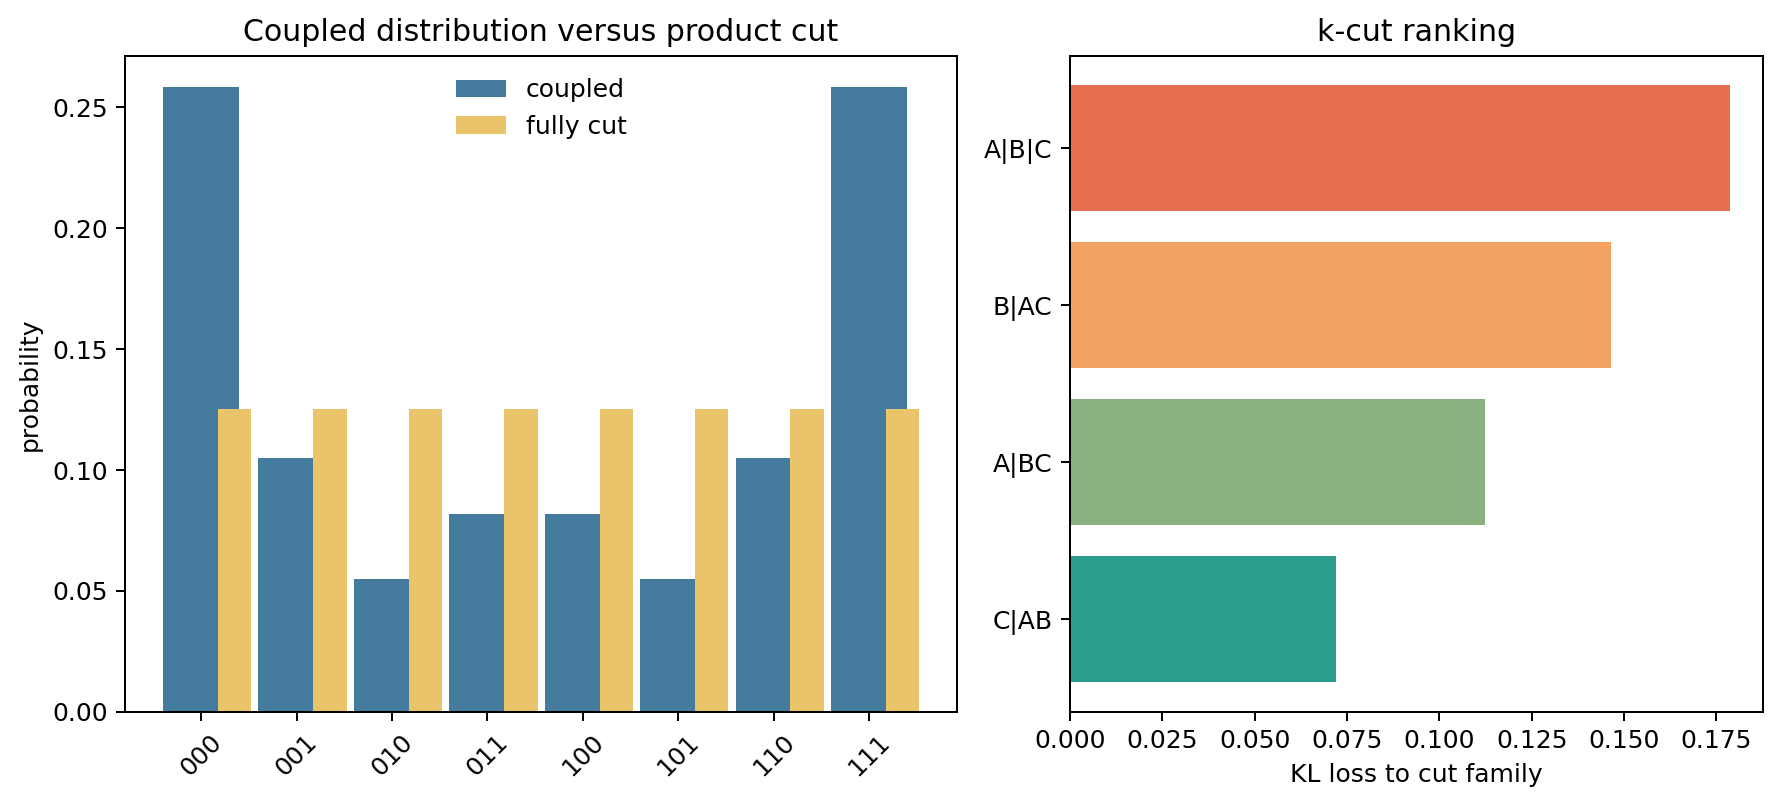

{
  "A|BC": 0.11229530141765717,
  "B|AC": 0.14650766953758076,
  "C|AB": 0.0721072268443153,
  "A|B|C": 0.17877873988949547
}


In [5]:
def normalize_vec(x):
    x = np.asarray(x, dtype=float)
    return x / x.sum()

def kl_vec(p, q):
    p = np.clip(normalize_vec(p), 1e-12, 1)
    q = np.clip(normalize_vec(q), 1e-12, 1)
    return float(np.sum(p * np.log(p / q)))

states = np.array([[a, b, c] for a in [0,1] for b in [0,1] for c in [0,1]])
energy = 0.9 * (states[:,0] == states[:,1]) + 0.65 * (states[:,1] == states[:,2]) - 0.25 * (states[:,0] != states[:,2])
joint = normalize_vec(np.exp(energy))

def marginal(dist, keep):
    keep = tuple(keep)
    out_shape = (2,) * len(keep)
    out = np.zeros(out_shape)
    for prob, state in zip(dist, states):
        out[tuple(state[list(keep)])] += prob
    return out

def product_cut(dist, blocks):
    result = np.ones(8)
    for block in blocks:
        marg = marginal(dist, block)
        for idx, state in enumerate(states):
            result[idx] *= marg[tuple(state[list(block)])]
    return normalize_vec(result)

cuts = {
    'A|BC': [(0,), (1,2)],
    'B|AC': [(1,), (0,2)],
    'C|AB': [(2,), (0,1)],
    'A|B|C': [(0,), (1,), (2,)],
}
cut_losses = {name: kl_vec(joint, product_cut(joint, blocks)) for name, blocks in cuts.items()}

fig, axes = plt.subplots(1, 2, figsize=(10, 4.6), gridspec_kw={'width_ratios':[1.2, 1]})
axes[0].bar(range(8), joint, color='#457b9d', label='coupled')
axes[0].bar(np.arange(8)+0.35, product_cut(joint, cuts['A|B|C']), width=0.35, color='#e9c46a', label='fully cut')
axes[0].set_xticks(range(8), [''.join(map(str, s)) for s in states], rotation=45)
axes[0].set_ylabel('probability')
axes[0].set_title('Coupled distribution versus product cut')
axes[0].legend(frameon=False)
ordered = sorted(cut_losses.items(), key=lambda kv: kv[1])
axes[1].barh([k for k, _ in ordered], [v for _, v in ordered], color=['#2a9d8f', '#8ab17d', '#f4a261', '#e76f51'])
axes[1].set_xlabel('KL loss to cut family')
axes[1].set_title('k-cut ranking')
fig.tight_layout()
artifact_names.append('k_cuts_information_loss.png')
savefig(fig, artifact_names[-1])
display_artifact(artifact_names[-1])
print(json.dumps(cut_losses, indent=2))
assert all(v >= -1e-12 for v in cut_losses.values())
assert cut_losses['A|B|C'] >= max(cut_losses['A|BC'], cut_losses['B|AC'], cut_losses['C|AB']) - 1e-12


## 5. Applied Lab: Integrated Information in a Tiny Neural Transition Model

Integrated-information calculations vary by formalism, but a common computational motif is stable: compare a coupled transition mechanism with mechanisms obtained by partitioning the system. If the coupled transition predicts the next state much better than every cut transition, the system has irreducible structure across that partition.

Here the mechanism is a two-node binary Markov chain. Each node tends to copy itself and is also pushed by the other node. We compare the full transition kernel with a cut kernel that predicts each next node from only its own present node. The divergence is averaged over present states. This is not a full IIT implementation; it is a transparent lab that isolates the chapter's geometric idea: forced factorization is a projection, and lost predictive information is a divergence.


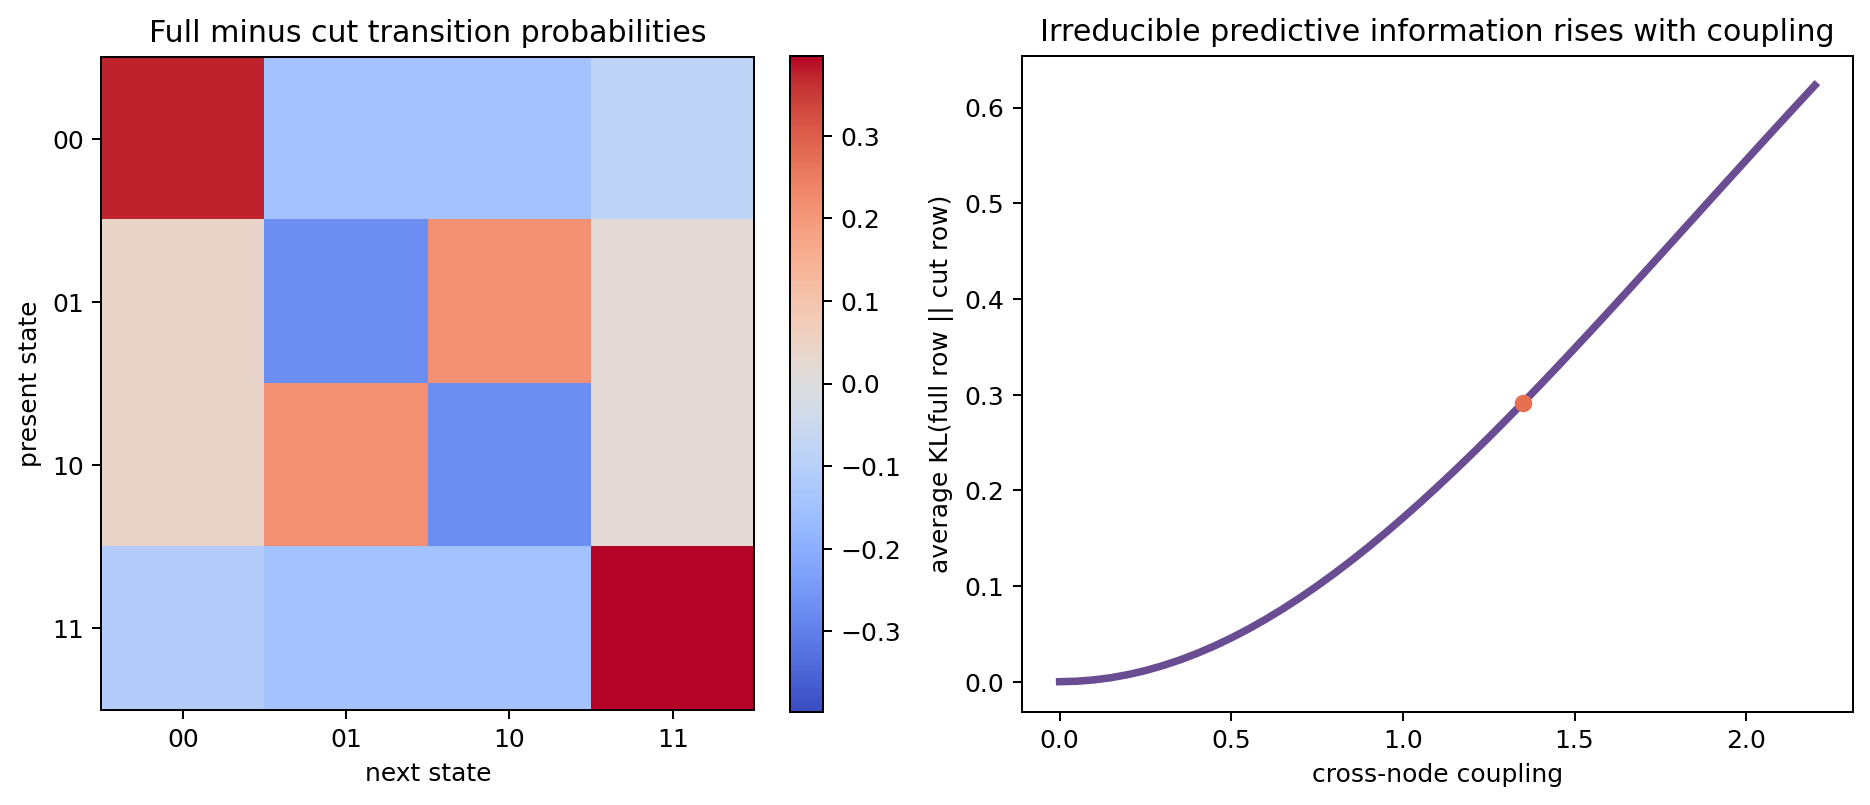

phi-like loss at coupling 1.35: 0.2916013541006566


In [6]:
present_states = np.array([[0,0], [0,1], [1,0], [1,1]])
next_states = present_states.copy()

def node_prob(next_bit, own, other, coupling=1.35, memory=1.1, bias=-0.15):
    field = bias + memory * (2 * own - 1) + coupling * (2 * other - 1)
    p1 = sigmoid(field)
    return p1 if next_bit == 1 else 1 - p1

def full_kernel(coupling=1.35):
    K = np.zeros((4, 4))
    for i, x in enumerate(present_states):
        for j, y in enumerate(next_states):
            K[i, j] = node_prob(y[0], x[0], x[1], coupling=coupling) * node_prob(y[1], x[1], x[0], coupling=coupling)
    return K / K.sum(axis=1, keepdims=True)

def cut_kernel(K):
    C = np.zeros_like(K)
    for i, x in enumerate(present_states):
        rows0 = np.where(present_states[:,0] == x[0])[0]
        rows1 = np.where(present_states[:,1] == x[1])[0]
        p_y0 = np.zeros(2)
        p_y1 = np.zeros(2)
        for row in rows0:
            for j, y in enumerate(next_states):
                p_y0[y[0]] += K[row, j] / len(rows0)
        for row in rows1:
            for j, y in enumerate(next_states):
                p_y1[y[1]] += K[row, j] / len(rows1)
        for j, y in enumerate(next_states):
            C[i, j] = p_y0[y[0]] * p_y1[y[1]]
    return C / C.sum(axis=1, keepdims=True)

def kernel_loss(K, C):
    return float(np.mean([kl_vec(K[i], C[i]) for i in range(K.shape[0])]))

couplings = np.linspace(0, 2.2, 45)
losses = []
for c in couplings:
    K = full_kernel(coupling=c)
    C = cut_kernel(K)
    losses.append(kernel_loss(K, C))
losses = np.array(losses)
K = full_kernel(coupling=1.35)
C = cut_kernel(K)
phi_value = kernel_loss(K, C)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.6), gridspec_kw={'width_ratios':[1, 1.15]})
im = axes[0].imshow(K - C, cmap='coolwarm', vmin=-np.max(np.abs(K-C)), vmax=np.max(np.abs(K-C)))
axes[0].set_xticks(range(4), [''.join(map(str, s)) for s in next_states])
axes[0].set_yticks(range(4), [''.join(map(str, s)) for s in present_states])
axes[0].set_xlabel('next state')
axes[0].set_ylabel('present state')
axes[0].set_title('Full minus cut transition probabilities')
fig.colorbar(im, ax=axes[0], fraction=0.046)
axes[1].plot(couplings, losses, color='#6a4c93', lw=3)
axes[1].scatter([1.35], [phi_value], color='#e76f51', zorder=4)
axes[1].set_xlabel('cross-node coupling')
axes[1].set_ylabel('average KL(full row || cut row)')
axes[1].set_title('Irreducible predictive information rises with coupling')
fig.tight_layout()
artifact_names.append('integrated_information_lab.png')
savefig(fig, artifact_names[-1])
display_artifact(artifact_names[-1])
print('phi-like loss at coupling 1.35:', phi_value)
assert phi_value > 0
assert losses[-1] > losses[0]


## Pitfalls and Design Checks

- Do not treat dual connections as two unrelated geometries. They are paired through the same metric.
- A flat coordinate chart is not the same thing as Euclidean geometry. Divergence contours can remain asymmetric and curved in ordinary plots.
- The canonical divergence depends on orientation. Check whether a formula is using `D(P, Q)` or `D(Q, P)` before comparing it with a familiar KL expression.
- Mixed coordinates are most useful when the projection problem respects the primal/dual split. If the submanifolds are not orthogonal in the dual sense, the Pythagorean identity should not be expected.
- k-cut and integrated-information examples are projections to restricted families. The modeling choice is the cut family; the geometric measurement is the divergence to that family.


In [7]:
sanity = {
    'chapter': '06-dual-affine-connections-dually-flat-manifold',
    'source_orientation': {'printed_pages': '131-161', 'pdf_pages': '141-171'},
    'artifacts': {name: {'exists': (ARTIFACT_DIR / name).exists(), 'bytes': (ARTIFACT_DIR / name).stat().st_size if (ARTIFACT_DIR / name).exists() else 0} for name in artifact_names},
    'checks': {
        'canonical_bernoulli_equals_reverse_kl_max_error': max_identity_error,
        'canonical_diagonal_max_error': diagonal_error,
        'canonical_surface_min_divergence': min_divergence,
        'mixed_coordinate_pythagorean_residual': pythagorean_residual,
        'cut_losses': cut_losses,
        'integrated_information_phi_like_loss': phi_value,
        'integrated_information_loss_increases': bool(losses[-1] > losses[0]),
    },
}
sanity['passed'] = bool(
    all(v['exists'] and v['bytes'] > 1000 for v in sanity['artifacts'].values())
    and max_identity_error < 1e-10
    and diagonal_error < 1e-10
    and abs(pythagorean_residual) < 1e-12
    and phi_value > 0
    and bool(losses[-1] > losses[0])
)
(ARTIFACT_DIR / 'final_sanity.json').write_text(json.dumps(sanity, indent=2), encoding='utf-8')
display_artifact('final_sanity.json', kind='json')
assert sanity['passed']


<IPython.core.display.JSON object>

## Takeaways

1. Dual connections are a compatibility structure: one metric, two affine rules, paired so that inner products differentiate cleanly.
2. Dually flat geometry turns convex analysis into geometry. Potentials, gradients, and Legendre transforms become coordinates, projections, and divergences.
3. Canonical divergence is the measurable convex gap between a point expressed in `theta` and another expressed in `eta`.
4. Mixed coordinates are not a cosmetic reparameterization. They reveal the orthogonal decomposition behind projection theorems.
5. k-cuts and integrated-information labs are applied projection problems: impose a factorization, compute the divergence from the coupled model, and interpret the leftover as lost interaction structure.


## Standalone Synthesis

The chapter focus is: Dual connections, metric and cubic tensors from divergence, alpha geometry, canonical divergence, mixed coordinates, neural firing, integrated information, and input-output economics.

Key computational translations:

- dual connections are paired through the metric. In the notebook this is represented by a concrete array, curve, surface, or metric object, then checked numerically so the reader can see the invariant rather than infer it from prose alone.
- a divergence contains metric and cubic-tensor information in its derivatives. In the notebook this is represented by a concrete array, curve, surface, or metric object, then checked numerically so the reader can see the invariant rather than infer it from prose alone.
- dually flat coordinates make canonical divergence computable. In the notebook this is represented by a concrete array, curve, surface, or metric object, then checked numerically so the reader can see the invariant rather than infer it from prose alone.
- mixed coordinates decompose interaction structure in finite systems. In the notebook this is represented by a concrete array, curve, surface, or metric object, then checked numerically so the reader can see the invariant rather than infer it from prose alone.

How to read the visual sequence:

- dual coordinate nets and canonical divergence surface. This visual should be read as evidence for a geometric claim, not as decoration; the surrounding code records the quantities that make the claim testable.
- finite-difference metric and cubic tensor from a divergence. This visual should be read as evidence for a geometric claim, not as decoration; the surrounding code records the quantities that make the claim testable.
- mixed-coordinate k-cut decomposition in a binary distribution. This visual should be read as evidence for a geometric claim, not as decoration; the surrounding code records the quantities that make the claim testable.
- neural firing interaction lattice with divergence contributions. This visual should be read as evidence for a geometric claim, not as decoration; the surrounding code records the quantities that make the claim testable.

This standalone synthesis is intentionally explicit about the contract between explanation, computation, and artifact. The reader should be able to close the PDF and still reconstruct the chapter's working picture: what the objects are, which coordinates are being used, what the visual is meant to reveal, and which numerical check guards the interpretation. When a divergence, metric, projection, or learning path appears, the notebook treats it as an inspectable mechanism. Changing the toy parameters is part of the lesson because it separates robust geometric behavior from an accidental drawing. If the saved check remains stable, the picture is carrying the idea; if the check fails, the diagram has become misleading and the model assumptions need to be revisited.

This standalone synthesis is intentionally explicit about the contract between explanation, computation, and artifact. The reader should be able to close the PDF and still reconstruct the chapter's working picture: what the objects are, which coordinates are being used, what the visual is meant to reveal, and which numerical check guards the interpretation. When a divergence, metric, projection, or learning path appears, the notebook treats it as an inspectable mechanism. Changing the toy parameters is part of the lesson because it separates robust geometric behavior from an accidental drawing. If the saved check remains stable, the picture is carrying the idea; if the check fails, the diagram has become misleading and the model assumptions need to be revisited.


## Course Standard Note

**Source span:** printed pages 131-161; PDF pages 141-171. The PDF is used only for source orientation, not as a required companion while reading this standalone notebook. The final_sanity evidence for this chapter is stored under `artifacts/chapter-06` using the chapter's local sanity JSON naming convention.
